# Basic CrocoDash Tutorial

Set up a basic regional ocean run!

A typical workflow of utilizing CrocoDash consists of four main steps:

1. Generate a regional MOM6 domain.
2. Create the CESM case.
3. Prepare ocean forcing data.
4. Build and run the case.


The first step in running CrocoDash is installing it! Please go to https://crocodile-cesm.github.io/CrocoDash/latest/installation.html to install CrocoDash!

# SECTION 1: Generate a regional MOM6 domain

We begin by defining a regional MOM6 domain using CrocoDash. To do so, we first generate a horizontal grid. We then generate the topography by remapping an existing bathymetric dataset to our horizontal grid. Finally, we define a vertical grid.

## Step 1.1: Horizontal Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [1]:
%load_ext autoreload 
%autoreload 2
from CrocoDash.grid import Grid

grid = Grid(
  resolution = 1/12, # in degrees
  xstart = 175, # min longitude in [0, 360]
  lenx = 25.0, # longitude extent in degrees
  ystart = 62.5, # min latitude in [-90, 90]
  leny = 5.0, # latitude extent in degrees
  name = "small_alaska",
)

In [2]:
%matplotlib ipympl
from CrocoDash.grid_creator import *

gc = GridCreator(grid)
gc


GridCreator(children=(VBox(children=(VBox(children=(HTML(value='<h3>Grid Creator &mdash; Edit Mode</h3>'), Flo…

```{admonition} Other ways to define your grid
:class: tip

- **Arctic or Antarctic domain?** Use a polar-projected grid with `Grid.from_projection()`. See [Grids, Section 4](grids.ipynb#grids-polar).
- **Pre-existing grid or supergrid?** Load it with `Grid.from_supergrid()` or extract a sub-domain with `Grid.subgrid_from_supergrid()`. See [Grids, Section 3](grids.ipynb#grids-pregenerated).
```

## Step 1.2: Topography


In [ ]:
from CrocoDash.topo import Topo

topo = Topo(
    grid = grid,
    min_depth = 0, # in meters
)

In [ ]:
from pathlib import Path

bathymetry_path= Path("<GEBCO_LOWRES>")
# The GEBCO bathymetry path on Derecho is: <GEBCO>

if not bathymetry_path.exists():
    raise FileNotFoundError("Bathymetry file not found, please replace with path to bathymetry file")

topo.set_from_dataset(
    bathymetry_path = bathymetry_path,
    longitude_coordinate_name="lon",
    latitude_coordinate_name="lat",
    vertical_coordinate_name="elevation",
    depth_method = "xesmf",
    mask_method = "dataset"
)

Slicing source bathymetry to domain: (175.0, 200.0) x (62.5, 67.5) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2026.nc):
    dlon = 15.0 arcsec  (0.004167°)
    dlat = 15.0 arcsec  (0.004167°)
    dx   ~ 217 m)
    dy   ~ 463 m

  Model grid (T-cell spacing):
    median = 6.03 km
    min    = 5.74 km
    max    = 6.29 km

  Resolution ratio (model dx / dataset dx):
    median = 27.7x
    max    = 28.9x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: high_res_regrid()  (Cressman + stats mask)
    Each model cell spans ~28 dataset pixels per side.
    Ocean-aware Cressman interpolation will meaningfully reduce
    land contamination of coastal depth estimates.
Resolution diagnostics recommend using stats-based masking, but xesmf-based depth was requested, so we will do a direct xesmf regrid anyway because it was explicitly requested, but be aware that this may lead to significant land contamination of coastal depth estimates
**NOTE**
            If bathymet

/glade/work/manishrv/conda-envs/CrocoDash/lib/python3.11/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Warning! This was an opionated workflow function that ran multiple steps in sequence. Please edit the mask manually if need be (Some depth methods, like cressman, are mask-aware and may need to be rerun)! 


In [5]:
%matplotlib ipympl
from CrocoDash.topo_editor import TopoEditor
TopoEditor(topo)

TopoEditor(children=(VBox(children=(HTML(value='<h2>Topo Editor</h2>'), VBox(children=(VBox(children=(HTML(val…

## Step 1.3: Vertical Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [6]:
from CrocoDash.vgrid import VGrid

vgrid  = VGrid.hyperbolic(
    nk = 20, # number of vertical levels
    depth = topo.max_depth,
    ratio=5.0 # target ratio of top to bottom layer thicknesses
)

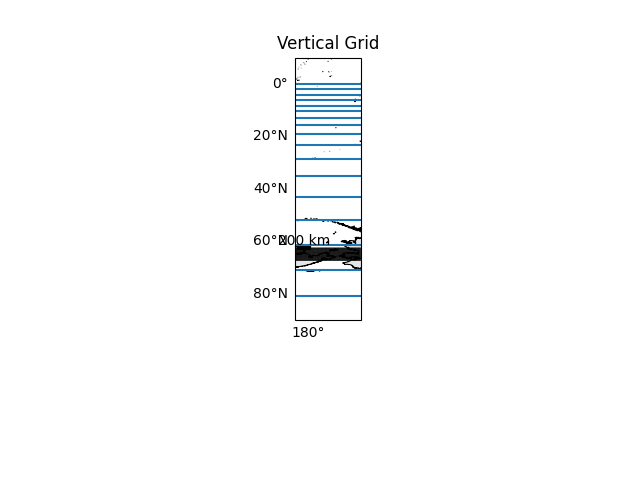

In [7]:
import matplotlib.pyplot as plt
plt.close()
# Create the plot
for depth in vgrid.zi:
    plt.axhline(y=depth, linestyle='-')  # Horizontal lines

plt.ylim(max(vgrid.zi) + 10, min(vgrid.zi) - 10)  # Invert y-axis so deeper values go down
plt.ylabel("Depth")
plt.title("Vertical Grid")
plt.show()

# SECTION 2: Create the CESM case

After generating the MOM6 domain, the next step is to create a CESM case using CrocoDash. This process is straightforward and involves instantiating the CrocoDash Case object. The Case object requires the following inputs:

 - CESM Source Directory: A local path to a compatible CESM source copy.
 - Case Name: A unique name for the CESM case.
 - Input Directory: The directory where all necessary input files will be written.
 - MOM6 Domain Objects: The horizontal grid, topography, and vertical grid created in the previous section.
 - Project ID: (Optional) A project ID, if required by the machine.
 - Compset: The set of models to be used in the Case. Standalone Ocean, Ocean-BGC, Ocean-Seaice, Ocean-Runoff

## Step 2.1: Specify case name and directories:

Begin by specifying the case name and the necessary directory paths. Ensure the CESM root directory points to your own local copy of CESM. Below is an example setup:

In [ ]:
from pathlib import Path

# CESM case (experiment) name
casename = "small_alaska"

# CESM source root (Update this path accordingly!!!)
cesmroot ="<CESM>"

# Place where all your input files go 
inputdir = Path("<inputdir>") / casename
    
# CESM case directory
caseroot = Path("<casedir>") / casename

## Step 2.2: Create the Case

To create the CESM case, instantiate the `Case` object as shown below. This will automatically set up the CESM case based on the provided inputs: The `cesmroot` argument specifies the path to your local CESM source directory.
The `caseroot` argument defines the directory where the case will be created. CrocoDash will handle all necessary namelist modifications and XML changes to align with the MOM6 domain objects generated earlier.

📖 [Case documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/2_case_setup.html)

### Compset quick-reference

The `compset` argument controls which model components are active. Start with the ocean-only default and swap or add stubs as needed:

| What you want | Change in `compset=` |
|---|---|
| Ocean only (default) | `compset="CR_JRA"` |
| + Sea ice (CICE6) | change `CR_JRA` → `GR_JRA` |
| + Biogeochemistry (MARBL) | add `%MARBL-BIO` to the MOM6 component, e.g. `MOM6%REGIONAL%MARBL-BIO` |
| + Data runoff (GLOFAS) | use `CR_JRA_GLOFAS` |
| + Data runoff (JRA) | use `CR_JRA` with `DROF%JRA` (see runoff notebook) |

For a deeper dive into each option:
- **CICE or BGC**: [Case Setup, Sections 3–4](case_setup.ipynb#case-cice)
- **Runoff (GLOFAS / JRA / custom)**: [Configure Forcings, Section 5](configure_forcings.ipynb#forcings-runoff)


In [9]:
from CrocoDash.case import Case

case = Case(
    cesmroot = cesmroot,
    caseroot = caseroot,
    inputdir = inputdir,
    ocn_grid = grid,
    ocn_vgrid = vgrid,
    ocn_topo = topo,
    project = 'ncgd0011',
    override = True,
    machine = "derecho",
    compset = "GR_JRA" # This is the alias of the compset, the longname (which is printed when you run this command) is 1850_DATM%JRA_SLND_CICE_MOM6%REGIONAL_SROF_SGLC_SWAV. Feel free to use either way!
)

INFO:	initialize:Initializing the visualCaseGen system...
INFO:  csp_solver:CspSolver initialized.


Creating case...

Running the create_newcase tool with the following command:

/glade/u/home/manishrv/work/installs/full_regional_cesm/cime/scripts/create_newcase --compset GR_JRA --res USER_RES --case /glade/u/home/manishrv/croc_cases/small_alaska --machine derecho --run-unsupported --pecount S --project ncgd0011 --non-local 

The create_newcase command was successful.

• Updating case xml variables to include newly generated ocean grid "small_alaska" with the following properties:
 nx: 300, ny: 60. ocean mesh: /glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice/ESMF_mesh_small_alaska_56400d.nc.

./xmlchange OCN_NX=300 --non-local

./xmlchange OCN_NY=60 --non-local

./xmlchange OCN_DOMAIN_MESH=/glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice/ESMF_mesh_small_alaska_56400d.nc --non-local

./xmlchange ICE_NX=300 --non-local

./xmlchange ICE_NY=60 --non-local

./xmlchange ICE_DOMAIN_MESH=/glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice/ESMF_mesh_small_a

INFO:	stage:SUCCESS: All stages are complete.


Case created successfully at /glade/u/home/manishrv/croc_cases/small_alaska.

To further customize, build, and run the case, navigate to the case directory in your terminal. To create another case, restart the notebook.

./xmlchange MOM6_MEMORY_MODE=dynamic_symmetric --non-local

The following additional configuration options are required to run and must be provided with any listed arguments in configure_forcings:
  - CICE: no arguments
  - conditions: boundaries, product_name, function_name, compset


# Section 3: Prepare ocean forcing data

We need to cut out our ocean forcing. The package expects an initial condition and one time-dependent segment per non-land boundary. Naming convention is `"east_unprocessed"` for segments and `"ic_unprocessed"` for the initial condition.

In this notebook, we are forcing with the Copernicus Marine "Glorys" reanalysis dataset. There's a function in the `CrocoDash` package, called `configure_forcings`, that generates a bash script to download the correct boundary forcing files for your experiment. First, you will need to create an account with Copernicus, and then call `copernicusmarine login` to set up your login details on your machine. Then you can run the `get_glorys_data.sh` bash script.

## Step 3.1 Configure Initial Conditions and Forcings

📖 [Configure forcings docs](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3a_configure_forcings.html) · [Available datasets](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html)

In [10]:
case.configure_forcings(
    date_range = ["2020-01-01 00:00:00", "2020-01-09 00:00:00"],
    boundaries=["south","north"],
    function_name="get_glorys_data_from_rda",
    cice_product_name="cice_restart",            
    cice_function_name="get_cice_restart_subset", 
    cice_function_args={
        "restart_path": "/glade/u/home/dbailey/b.e30_alpha09b.B1850C_MTso.ne30_t233_wgx3.360.cice.r.0201-01-01-00000.nc",
        "grid_path": "/glade/campaign/cesm/community/omwg/grids/tx2_3v3_grid.nc",  # the restart's companion grid file
    },
)

INFO:CrocoDash.forcing.base:[SKIP] BGC incompatible with compset
INFO:CrocoDash.forcing.base:[SKIP] BGCIC incompatible with compset
INFO:CrocoDash.forcing.base:[SKIP] BGCIronForcing incompatible with compset
INFO:CrocoDash.forcing.base:[SKIP] BGCRiverNutrients incompatible with compset
INFO:CrocoDash.forcing.base:[SKIP] Chl missing args: ['chl_processed_filepath']
INFO:CrocoDash.forcing.base:[REQUIRED] Activating CICE
INFO:CrocoDash.forcing.base:[REQUIRED] Activating conditions
INFO:CrocoDash.forcing.base:[SKIP] Runoff incompatible with compset
INFO:CrocoDash.forcing.base:[SKIP] tides missing args: ['tpxo_elevation_filepath', 'tpxo_velocity_filepath', 'tidal_constituents']
INFO:CrocoDash.forcing.base:Configuring CICE
INFO:CrocoDash.forcing.base:Configuring conditions


Adding parameter changes to user_nl_cice:

  ice_ic = '/glade/u/home/manishrv/scratch/croc_input/small_alaska/sea_ice/cice_forcing.nc'

Adding parameter changes to user_nl_cice:

  ns_boundary_type = 'zero_gradient'

Adding parameter changes to user_nl_cice:

  ew_boundary_type = 'zero_gradient'

Adding parameter changes to user_nl_cice:

  close_boundaries = .false.

Adding parameter changes to user_nl_cice:

  advect = 'upwind'

Adding parameter changes to user_nl_cice:

  restart_ext = .true.

Adding parameter changes to user_nl_cice:

  restore_ice = .true.

Adding parameter changes to user_nl_cice:

  trestore = 90

Adding parameter changes to user_nl_mom:

  ! Initial conditions
  INIT_LAYERS_FROM_Z_FILE = True
  Z_INIT_ALE_REMAPPING = True
  TEMP_SALT_INIT_VERTICAL_REMAP_ONLY = True
  DEPRESS_INITIAL_SURFACE = True
  VELOCITY_CONFIG = file
  TEMP_SALT_Z_INIT_FILE = init_tracers.nc
  SURFACE_HEIGHT_IC_FILE = init_eta.nc
  VELOCITY_FILE = init_vel.nc
  Z_INIT_FILE_PTEMP_VAR = temp

```{admonition} Optional forcing additions
:class: tip

You can extend `configure_forcings` with any of these before calling `process_forcings`:

- **Tides**: [Configure Forcings, Section 3](configure_forcings.ipynb#forcings-tides)
- **Chlorophyll**: [Configure Forcings, Section 4](configure_forcings.ipynb#forcings-chlorophyll)
- **Alternative data products** (not GLORYS), [Configure Forcings, Section 2](configure_forcings.ipynb#forcings-data-products)
- **Long runs / offline OBC**: [Process Forcings, Section 2](process_forcings.ipynb#process-offline)
```

##  Step 3.3: Process forcing data

In this final step, we call the `process_forcings` method of CrocoDash to cut out and interpolate the initial condition as well as all boundaries. CrocoDash also updates MOM6 runtime parameters and CESM xml variables accordingly.

In [11]:
case.process_forcings()

INFO:CrocoDash.forcing.obc:Using tmask-derived bounding boxes for OBC data download.
INFO:CrocoDash.forcing.obc:GET [south]: 2020-01-01 → 2020-01-09
INFO:GLORYS:Downloading Glorys data from RDA to /glade/u/home/manishrv/scratch/croc_input/small_alaska/extract_forcings/raw_data/south_unprocessed.2020-01-01_2020-01-09.nc
INFO:CrocoDash.forcing.obc:GET [north]: 2020-01-01 → 2020-01-09
INFO:GLORYS:Downloading Glorys data from RDA to /glade/u/home/manishrv/scratch/croc_input/small_alaska/extract_forcings/raw_data/north_unprocessed.2020-01-01_2020-01-09.nc
INFO:CrocoDash.forcing.obc:REGRID [south]: 9-day slices


No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping


INFO:CrocoDash.forcing.obc:Saved regridded file as forcing_obc_segment_001_2020-01-01_2020-01-09.nc
INFO:CrocoDash.forcing.obc:REGRID [north]: 9-day slices


No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping


INFO:CrocoDash.forcing.obc:Saved regridded file as forcing_obc_segment_002_2020-01-01_2020-01-09.nc
INFO:CrocoDash.forcing.obc:MERGE [south]
INFO:CrocoDash.forcing.obc:Saved merged boundary at /glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice/forcing_obc_segment_001.nc
INFO:CrocoDash.forcing.obc:MERGE [north]
INFO:CrocoDash.forcing.obc:Saved merged boundary at /glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice/forcing_obc_segment_002.nc
INFO:CrocoDash.forcing.obc:OBC processing complete.


--- xESMF Regridding Info ---
  Source:        nj=40, ni=44, ncat=5  (8,800 points)  [4.96 MB]
  Destination:   ny=62, nx=302  (18,724 points)  [0.30 MB]
  Method:        nearest_s2d
  Weights:       generating new weights
  Periodic:      False
  Locstream out: False
-----------------------------
Generating regridding weights using xESMF with method 'nearest_s2d'...
--- xESMF Regridding Info ---
  Source:        nj=40, ni=44  (1,760 points)  [0.24 MB]
  Destination:   ny=62, nx=302  (18,724 points)  [0.30 MB]
  Method:        nearest_s2d
  Weights:       generating new weights
  Periodic:      False
  Locstream out: False
-----------------------------
Generating regridding weights using xESMF with method 'nearest_s2d'...


INFO:CrocoDash.forcing.ic:[GLORYS.get_glorys_data_from_rda] Usage: Requires read access to /glade/campaign/collections/rda/data/d010049/ and the CrocoDash conda environment.
INFO:GLORYS:Downloading Glorys data from RDA to /glade/u/home/manishrv/scratch/croc_input/small_alaska/extract_forcings/raw_data/ic_unprocessed.nc


This means that some areas may only have one or two layers between the surface and sea floor. 
For increased stability, consider increasing the minimum depth, or adjusting the vertical coordinate to add more layers near the surface.
No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping
Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

INFO:CrocoDash.forcing.mom6:Start mom6_forge fill...
INFO:CrocoDash.forcing.mom6:...end mom6_forge fill.
INFO:CrocoDash.forcing.ic:Successfully retrieved GLORYS initial condition data located in /glade/u/home/manishrv/scratch/croc_input/small_alaska/ocnice directory.


[timing] bc: 91.4s  cice: 0.9s  ic: 13.3s  total: 105.7s
Case is ready to be built: /glade/u/home/manishrv/croc_cases/small_alaska


In [ ]:
print("You can now build and run your case at",caseroot)

# Section 4: Build and run the case

After completing the previous steps, you are ready to build and run your CESM case. Begin by navigating to the case root directory specified during the case creation. Before proceeding, review the `user_nl_mom` file located in the case directory. This file contains MOM6 parameter settings that were automatically generated by CrocoDash. Carefully examine these parameters and make any necessary adjustments to fine-tune the model for your specific requirements. While CrocoDash aims to provide a solid starting point, further tuning and adjustments are typically necessary to improve the model for your use case.

Once you have reviewed and modified the parameters as needed, you can build and execute the case using the following commands: 
```
qcmd -- ./case.build
./case.submit
```

# Where to go from here?

This tutorial covered the basics of CrocoDash. Extend it with features or jump into a real-world example:

## Add more components
- [Case Setup: Coupling (CICE / BGC)](case_setup.ipynb#case-cice): sea ice or biogeochemistry
- [Configure Forcings: Tides](configure_forcings.ipynb#forcings-tides)
- [Configure Forcings: Chlorophyll](configure_forcings.ipynb#forcings-chlorophyll)
- [Configure Forcings: Runoff](configure_forcings.ipynb#forcings-runoff)

## Try a different domain
- [Grids: Polar Projections](grids.ipynb#grids-polar): Arctic & Antarctic domains
- [Grids: Pre-Generated or Subset](grids.ipynb#grids-pregenerated): pre-generated supergrid or global subset

## Real-world examples
- [NWA12 (North-West Atlantic 1/12°)](use_cases/three_boundary.ipynb)
- [Antarctic CICE coupled run](use_cases/mom6_cice_antarctica.ipynb)
- [Low-resolution domain for data assimilation](use_cases/three_boundary_from_t232.ipynb)

## Explore model output
- [mom6-tools Diagnostics](../mom6_tools.md)
- [CARIB12 EKE Analysis](../model2obs/CARIB12_EKE_TS.ipynb)
- [Model–Observation Comparison](../model2obs/model-obs_comparison.md)

## Full documentation

The complete CrocoDash reference is at **[https://crocodile-cesm.github.io/CrocoDash/latest/](https://crocodile-cesm.github.io/CrocoDash/latest/)**:

- [Installation](https://crocodile-cesm.github.io/CrocoDash/latest/installation.html)
- [Grids (horizontal, topography, vertical)](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)
- [Available datasets](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html)
- [Forcing extraction](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3b_process_forcings.html)
- [Forcing configurations](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3a_configure_forcings.html)
- [Bundling & forking cases](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/shareable.html)
- [API reference](https://crocodile-cesm.github.io/CrocoDash/latest/api-docs/modules.html)